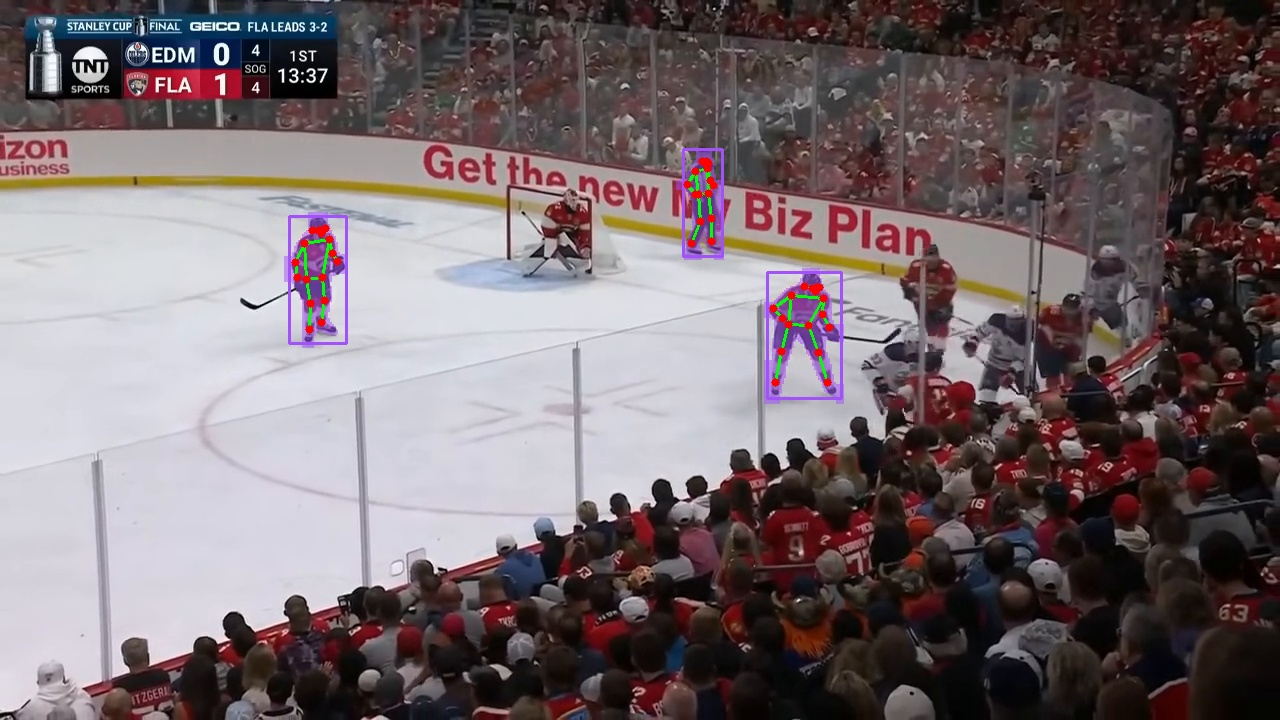

Frame 590 traitée...
Vidéo finalisée : video/NHL_output_yolo_vitpose.mp4


In [1]:
import cv2
import torch
import numpy as np
import supervision as sv
from PIL import Image
from transformers import AutoProcessor, VitPoseForPoseEstimation
from IPython.display import display, Image as IPImage, clear_output
from ultralytics import YOLO

# --- CONFIGURATION CHEMINS ---
video_path = "video/NHL_vid.mp4" 
output_path = "video/NHL_output_yolo_vitpose.mp4"

# --- DETECT HARDWARE ET SELECTION DU MODELE ---
if torch.xpu.is_available():
    device = "xpu"
    YOLO_MODEL_PATH = "models/yolo26l-seg_int8_openvino_model" 
elif torch.cuda.is_available():
    device = "cuda"
    YOLO_MODEL_PATH = "models/yolo26l-seg.pt"
else:
    device = "cpu"
    YOLO_MODEL_PATH = "models/yolo26l-seg.pt" # PyTorch standard

print(f"Using device: {device}")
print(f"Using YOLO model: {YOLO_MODEL_PATH}")

# --- CHARGEMENT DES MODÈLES ---
print("Loading YOLO Segmentation model...")
seg_yolo_model = YOLO(YOLO_MODEL_PATH) 

print("Loading ViTPose model...")
pose_image_processor = AutoProcessor.from_pretrained("usyd-community/vitpose-base-simple")
pose_model = VitPoseForPoseEstimation.from_pretrained("usyd-community/vitpose-base-simple").to(device)

# --- ANNOTATEURS SUPERVISION ---
mask_annotator = sv.MaskAnnotator(opacity=0.5)
box_annotator = sv.BoxAnnotator(thickness=2)
edge_annotator = sv.EdgeAnnotator(color=sv.Color.GREEN, thickness=2)
vertex_annotator = sv.VertexAnnotator(color=sv.Color.RED, radius=4)

# --- TRAITEMENT VIDÉO ---
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Erreur: Impossible d'ouvrir la vidéo {video_path}")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print("Début de l'inférence...")
    try:
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            
            # Inférence YOLO (Détection + Segmentation) pour la classe personne (0)
            results = seg_yolo_model.predict(frame, classes=[0], conf=0.5, verbose=False)
            
            # Conversion Supervision pour faciliter l'annotation et l'extraction
            detections = sv.Detections.from_ultralytics(results[0])
            
            if len(detections) > 0:
                # --- Préparation pour ViTPose ---
                # Format attendu par ViTPose : [x, y, w, h]
                vit_boxes = detections.xyxy.copy()
                vit_boxes[:, 2] = vit_boxes[:, 2] - vit_boxes[:, 0] # width
                vit_boxes[:, 3] = vit_boxes[:, 3] - vit_boxes[:, 1] # height

                # Conversion PIL pour le processor
                rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                pil_image = Image.fromarray(rgb_frame)

                # --- Inférence ViTPose ---
                pose_inputs = pose_image_processor(pil_image, boxes=[vit_boxes.tolist()], return_tensors="pt").to(device)
                with torch.no_grad():
                    pose_outputs = pose_model(**pose_inputs)
                
                pose_results = pose_image_processor.post_process_pose_estimation(pose_outputs, boxes=[vit_boxes.tolist()])
                image_pose_result = pose_results[0]

                # Extraction des points de squelette au format Supervision
                xy = torch.stack([res['keypoints'] for res in image_pose_result]).cpu().numpy()
                scores = torch.stack([res['scores'] for res in image_pose_result]).cpu().numpy()
                key_points = sv.KeyPoints(xy=xy, confidence=scores)

                # --- Annotation Multi-couches ---
                annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=detections)
                annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
                annotated_frame = edge_annotator.annotate(scene=annotated_frame, key_points=key_points)
                annotated_frame = vertex_annotator.annotate(scene=annotated_frame, key_points=key_points)
            else:
                annotated_frame = frame

            out.write(annotated_frame)

            # Affichage interactif Jupyter toutes les 10 frames
            if frame_idx % 10 == 0:
                _, buffer = cv2.imencode('.jpg', annotated_frame)
                clear_output(wait=True)
                display(IPImage(data=buffer))
                print(f"Frame {frame_idx} traitée...")
            
            frame_idx += 1

    except KeyboardInterrupt:
        print("\nInterrompu par l'utilisateur.")
    finally:
        cap.release()
        out.release()
        print(f"Vidéo finalisée : {output_path}")